(614, 13)
    Loan_ID Gender Married Dependents Education Self_Employed  \
0  LP001002   Male      No          0  Graduate            No   
1  LP001003   Male     Yes          1  Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----

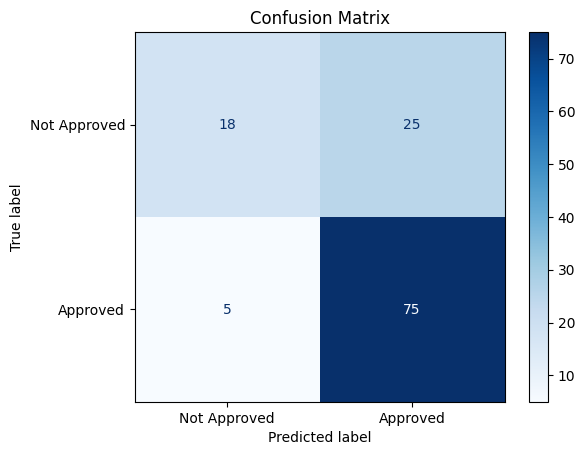


📌 Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



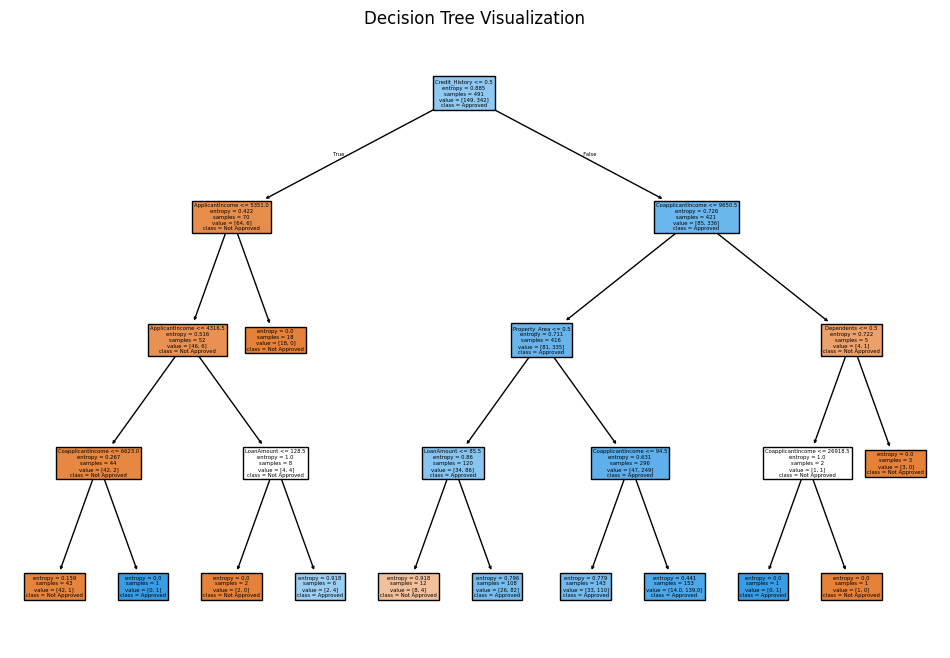

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# ---- Step 1: Load the Dataset ----
file_path = "train_ctrUa4K.csv"  # Update the path if needed
data = pd.read_csv(file_path)

# Displaying dataset info
print(data.shape)
print(data.head(2))
print(data.keys())
print(data.info())
print(data.isnull().sum())

# ---- Step 2: Handle Missing Values (Fixed) ----
# Fill missing values in numerical columns with their mean
data = data.assign(
    LoanAmount=data['LoanAmount'].fillna(data['LoanAmount'].mean()),
    Loan_Amount_Term=data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mean()),
    Credit_History=data['Credit_History'].fillna(data['Credit_History'].mode()[0])
)

# Fill missing categorical values with the mode
categorical_columns = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# ---- Step 3: Encode Categorical Variables ----
label_enc = LabelEncoder()
for col in categorical_columns + ['Education', 'Property_Area', 'Loan_Status']:
    data[col] = label_enc.fit_transform(data[col])

# ---- Step 4: Feature Selection ----
X = data.drop(columns=['Loan_ID', 'Loan_Status'])  # Remove Loan_ID & target variable
y = data['Loan_Status']  # Target variable (Loan Approved: 1, Not Approved: 0)

# ---- Step 5: Split Data into Training & Testing Sets ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Step 6: Train Decision Tree Classifier ----
dt_classifier = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
dt_classifier.fit(X_train, y_train)

# ---- Step 7: Model Predictions ----
y_pred = dt_classifier.predict(X_test)

# ---- Step 8: Model Evaluation ----
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📌 Model Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Not Approved", "Approved"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n📌 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ---- Step 9: Visualizing Decision Tree ----
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(dt_classifier, feature_names=X.columns, class_names=["Not Approved", "Approved"], filled=True)
plt.title("Decision Tree Visualization")
plt.show()


In [3]:
# ---- Step 2.5: Feature Engineering - Create TotalIncome ----
# Combine ApplicantIncome and CoapplicantIncome into a new TotalIncome feature
data['TotalIncome'] = data['ApplicantIncome'] + data['CoapplicantIncome']

print(f"Sample of TotalIncome values:\n{data[['ApplicantIncome', 'CoapplicantIncome', 'TotalIncome']].head()}")

Sample of TotalIncome values:
   ApplicantIncome  CoapplicantIncome  TotalIncome
0             5849                0.0       5849.0
1             4583             1508.0       6091.0
2             3000                0.0       3000.0
3             2583             2358.0       4941.0
4             6000                0.0       6000.0


In [4]:
# ---- Step 2.6: Feature Engineering - Create Loan_Income_Ratio ----
# Create a new feature to assess affordability: Loan amount relative to total income
data['Loan_Income_Ratio'] = data['LoanAmount'] / data['TotalIncome']

print(f"Sample of Loan_Income_Ratio values:\n{data[['LoanAmount', 'TotalIncome', 'Loan_Income_Ratio']].head()}")
print(f"\nLoan_Income_Ratio Statistics:")
print(data['Loan_Income_Ratio'].describe())

Sample of Loan_Income_Ratio values:
   LoanAmount  TotalIncome  Loan_Income_Ratio
0  146.412162       5849.0           0.025032
1  128.000000       6091.0           0.021015
2   66.000000       3000.0           0.022000
3  120.000000       4941.0           0.024287
4  141.000000       6000.0           0.023500

Loan_Income_Ratio Statistics:
count    614.000000
mean       0.024017
std        0.008947
min        0.002523
25%        0.019362
50%        0.024174
75%        0.028345
max        0.082712
Name: Loan_Income_Ratio, dtype: float64


In [6]:
# ---- Step 10: Train Baseline Model (Without New Features) ----
# Create a copy of data without the engineered features for baseline comparison
data_baseline = data.drop(columns=['TotalIncome', 'Loan_Income_Ratio'])

X_baseline = data_baseline.drop(columns=['Loan_ID', 'Loan_Status'])
y_baseline = data_baseline['Loan_Status']

X_train_bl, X_test_bl, y_train_bl, y_test_bl = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42)

# Train baseline decision tree
dt_baseline = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
dt_baseline.fit(X_train_bl, y_train_bl)

# Predictions
y_pred_baseline = dt_baseline.predict(X_test_bl)
accuracy_baseline = accuracy_score(y_test_bl, y_pred_baseline)

# ---- Step 11: Train Feature-Engineered Model (With New Features) ----
X_fe = data.drop(columns=['Loan_ID', 'Loan_Status'])
y_fe = data['Loan_Status']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

# Train feature-engineered decision tree
dt_fe = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
dt_fe.fit(X_train_fe, y_train_fe)

# Predictions
y_pred_fe = dt_fe.predict(X_test_fe)
accuracy_fe = accuracy_score(y_test_fe, y_pred_fe)

print(f"Baseline Accuracy: {accuracy_baseline:.4f}")
print(f"Feature-Engineered Accuracy: {accuracy_fe:.4f}")
print(f"Improvement: {(accuracy_fe - accuracy_baseline):.4f}")

Baseline Accuracy: 0.7561
Feature-Engineered Accuracy: 0.7805
Improvement: 0.0244


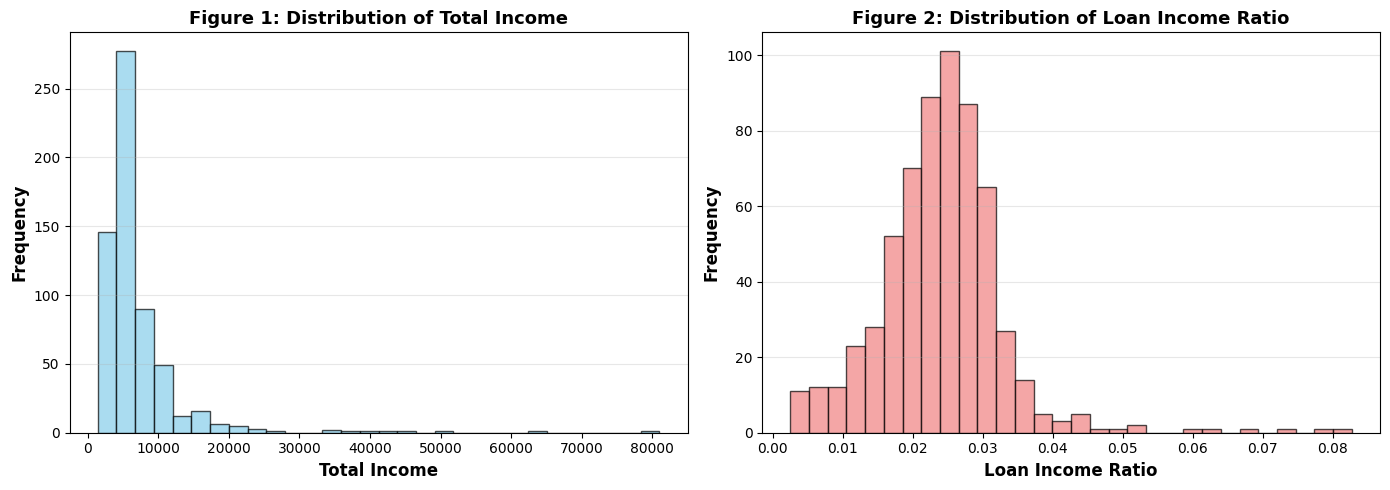

/tmp/ipykernel_377323/3032658946.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([loan_rejected, loan_approved], labels=['Not Approved', 'Approved'], patch_artist=True,


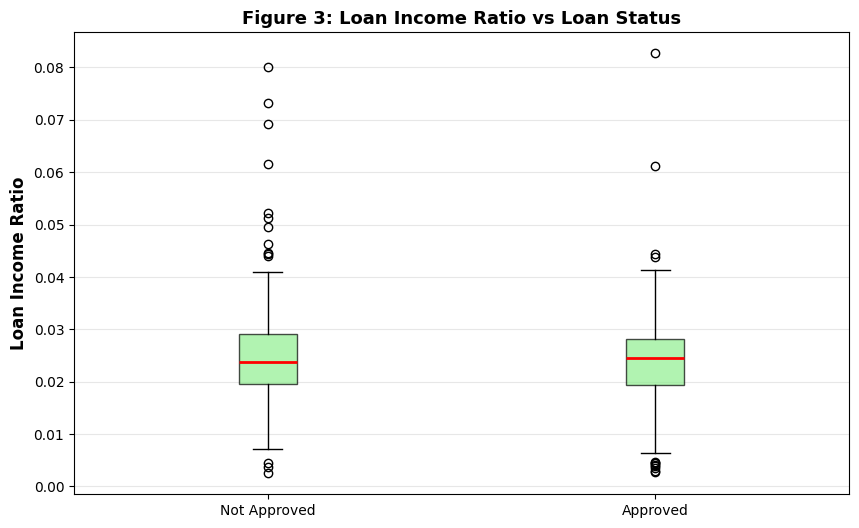

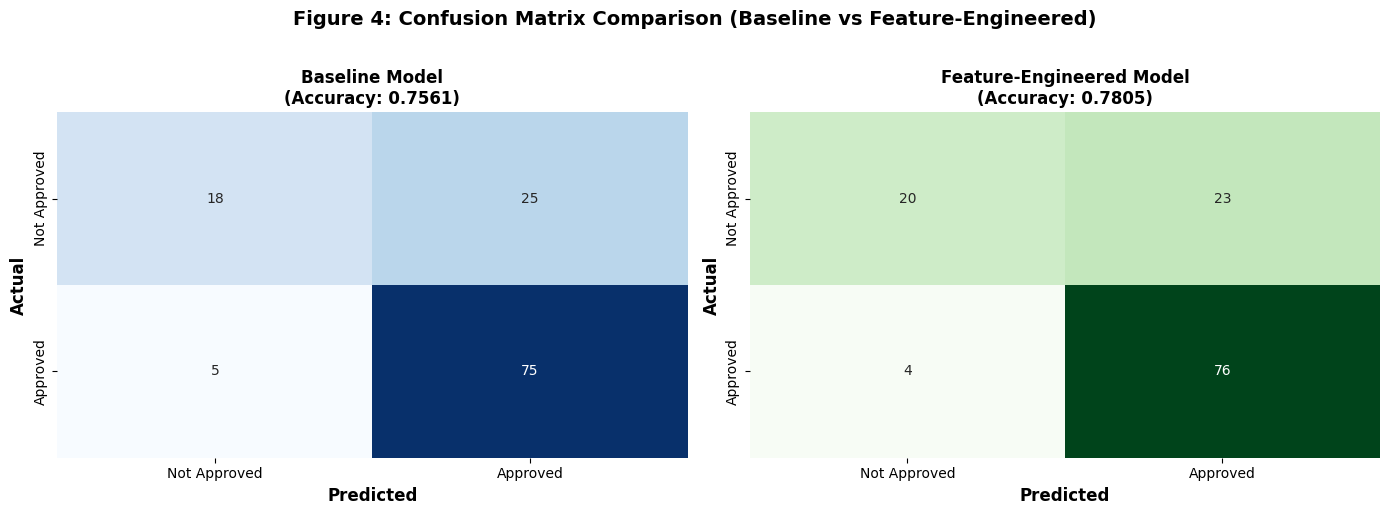

/tmp/ipykernel_377323/3032658946.py:133: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_377323/3032658946.py:133: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/dev-algo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev-algo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


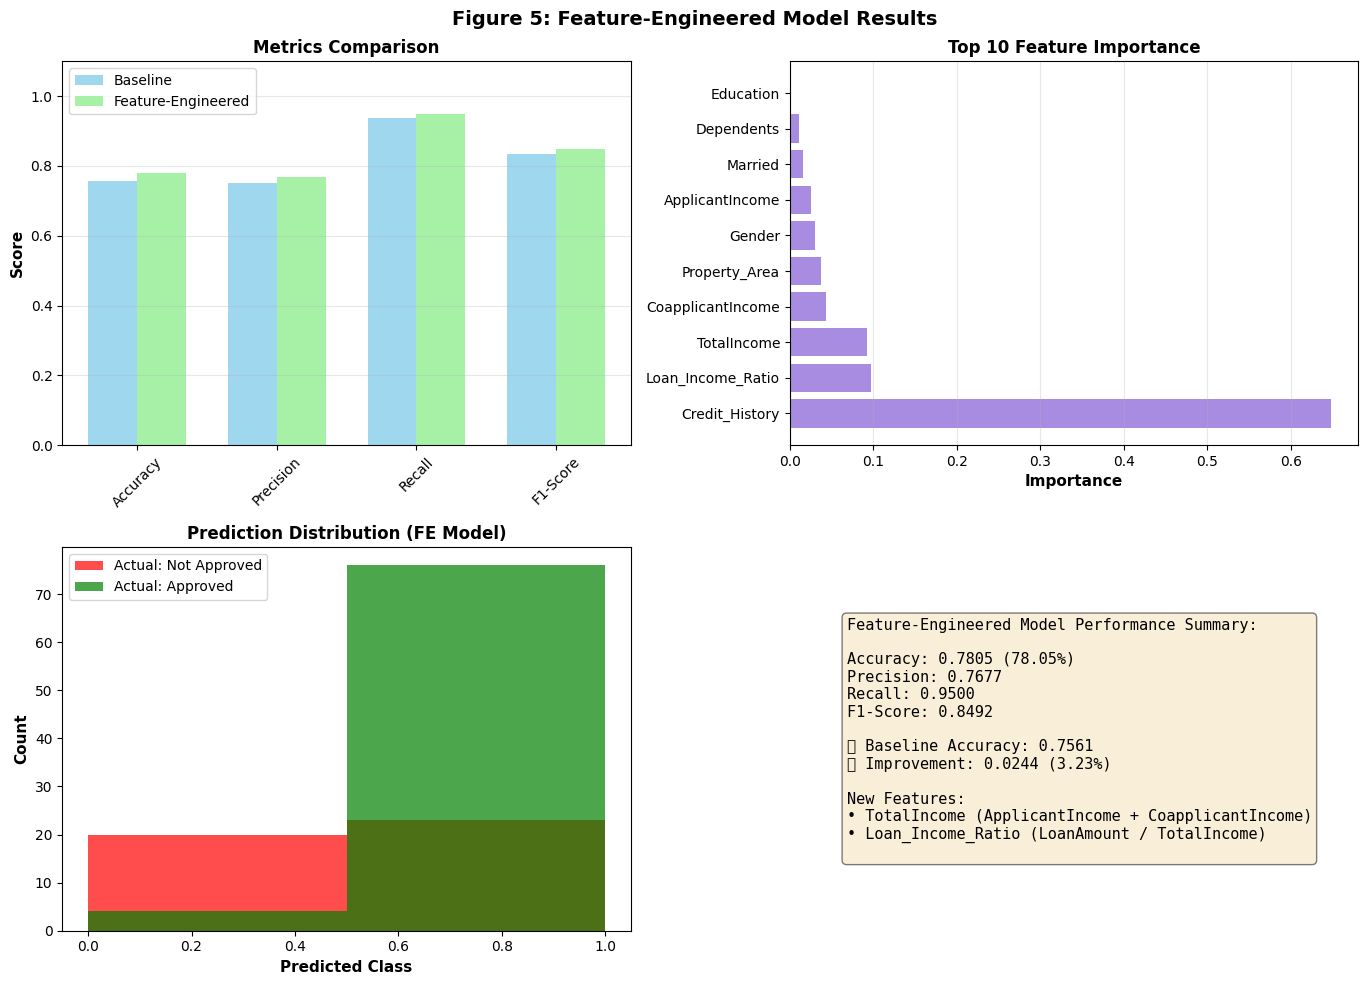


ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!


In [8]:
# ---- Step 12: Create Comprehensive Visualizations ----

# Figure 1 & 2: Distribution of Total Income and Loan Income Ratio (Side by Side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 1: Total Income Distribution
axes[0].hist(data['TotalIncome'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Income', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Figure 1: Distribution of Total Income', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Figure 2: Loan Income Ratio Distribution
axes[1].hist(data['Loan_Income_Ratio'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Loan Income Ratio', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Figure 2: Distribution of Loan Income Ratio', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 3: Loan Income Ratio vs Loan Status
fig, ax = plt.subplots(figsize=(10, 6))
loan_approved = data[data['Loan_Status'] == 1]['Loan_Income_Ratio']
loan_rejected = data[data['Loan_Status'] == 0]['Loan_Income_Ratio']

ax.boxplot([loan_rejected, loan_approved], labels=['Not Approved', 'Approved'], patch_artist=True,
           boxprops=dict(facecolor='lightgreen', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Loan Income Ratio', fontsize=12, fontweight='bold')
ax.set_title('Figure 3: Loan Income Ratio vs Loan Status', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.show()

# Figure 4: Confusion Matrix Comparison (Baseline vs Feature-Engineered)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline Confusion Matrix
conf_matrix_bl = confusion_matrix(y_test_bl, y_pred_baseline)
sns.heatmap(conf_matrix_bl, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
axes[0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_title(f'Baseline Model\n(Accuracy: {accuracy_baseline:.4f})', fontsize=12, fontweight='bold')

# Feature-Engineered Confusion Matrix
conf_matrix_fe = confusion_matrix(y_test_fe, y_pred_fe)
sns.heatmap(conf_matrix_fe, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Not Approved', 'Approved'], yticklabels=['Not Approved', 'Approved'])
axes[1].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_title(f'Feature-Engineered Model\n(Accuracy: {accuracy_fe:.4f})', fontsize=12, fontweight='bold')

fig.suptitle('Figure 4: Confusion Matrix Comparison (Baseline vs Feature-Engineered)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Figure 5: Feature-Engineered Model Results Summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Classification Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_metrics = [
    accuracy_baseline,
    precision_score(y_test_bl, y_pred_baseline),
    recall_score(y_test_bl, y_pred_baseline),
    f1_score(y_test_bl, y_pred_baseline)
]
fe_metrics = [
    accuracy_fe,
    precision_score(y_test_fe, y_pred_fe),
    recall_score(y_test_fe, y_pred_fe),
    f1_score(y_test_fe, y_pred_fe)
]

# Metrics Comparison Bar Chart
x = np.arange(len(metrics_names))
width = 0.35
axes[0, 0].bar(x - width/2, baseline_metrics, width, label='Baseline', color='skyblue', alpha=0.8)
axes[0, 0].bar(x + width/2, fe_metrics, width, label='Feature-Engineered', color='lightgreen', alpha=0.8)
axes[0, 0].set_ylabel('Score', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_names, rotation=45)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1.1])
axes[0, 0].grid(axis='y', alpha=0.3)

# Feature Importance (Top 10)
feature_importance_fe = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': dt_fe.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

axes[0, 1].barh(feature_importance_fe['Feature'], feature_importance_fe['Importance'], color='mediumpurple', alpha=0.8)
axes[0, 1].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Top 10 Feature Importance', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Prediction Distribution for FE Model
axes[1, 0].hist(y_pred_fe[y_test_fe == 0], bins=2, label='Actual: Not Approved', alpha=0.7, color='red')
axes[1, 0].hist(y_pred_fe[y_test_fe == 1], bins=2, label='Actual: Approved', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Predicted Class', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Prediction Distribution (FE Model)', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# Summary Statistics
summary_text = f"""Feature-Engineered Model Performance Summary:

Accuracy: {accuracy_fe:.4f} ({accuracy_fe*100:.2f}%)
Precision: {precision_score(y_test_fe, y_pred_fe):.4f}
Recall: {recall_score(y_test_fe, y_pred_fe):.4f}
F1-Score: {f1_score(y_test_fe, y_pred_fe):.4f}

📊 Baseline Accuracy: {accuracy_baseline:.4f}
📈 Improvement: {(accuracy_fe-accuracy_baseline):.4f} ({((accuracy_fe-accuracy_baseline)/accuracy_baseline*100):.2f}%)

New Features:
• TotalIncome (ApplicantIncome + CoapplicantIncome)
• Loan_Income_Ratio (LoanAmount / TotalIncome)
"""

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
                fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

fig.suptitle('Figure 5: Feature-Engineered Model Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!")
print("="*70)